In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *
print("Fixed Income Library is loaded.")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

Added to sys.path:/ /Users/nirvana/Documents/NYUQuantClub1
Fixed Income Library is loaded.


### Prepare Model and Valuation Parameters

In [2]:
### load model back in
path = 'serialized/yc_model_calibrated.pickle'
yc_model : Model = qfReadModelFromFile(path)
# check
vdate = yc_model.value_date
display(vdate)

Date(11,2,2026)

In [8]:
### everything is collateralised in RFR
fi_vp = qfCreateValuationParameters('FUNDING INDEX PARAMETER', {'Funding Index' : 'SOFR-1B-FLAT'})
vp_collection = qfCreateValuationParametersCollection([fi_vp])

### Test Risk

In [9]:
effective_date = '2031-10-17'
termination_date = '2041-10-17'
pay_offset = '2D'
on_index = 'SOFR-1B'
fixed_rate = 0.0357
pay_or_rec = 'pay'
notional = 1e6
accrual_peroid = '1Y'
accrual_basis = 'ACT/360'
floating_leg_accrual_period = '1Y'
business_day_convention = 'F'
holiday_convention = 'USGS'
spread = 0.02
compounding_method = 'compound'
product_on_rfr_swap = qfCreateProductRFRSwap(
    effective_date,
    termination_date,
    pay_offset,
    on_index,
    fixed_rate,
    pay_or_rec,
    notional,
    accrual_peroid,
    accrual_basis)
qfDisplayProduct(product_on_rfr_swap)

,Name,Value
0,Product Type,PRODUCT_RFR_SWAP
1,Notional,1000000.0
2,Currency,USD
3,Long Or Short,LONG
4,Effective Date,2031-10-17
5,Termination Date,2041-10-17
6,Payment Offset,2D
7,ON Index,SOFRON Actual/360
8,Fixed Rate,0.0357
9,Pay Or Receive,PAY


In [10]:
### pv
pv_base = qfCreateValueReport(yc_model, product_on_rfr_swap, vp_collection, 'pv')[0][1]
print(f'Base pv is {pv_base:.2f}.')

Base pv is 55071.45.


In [14]:
### risk
df_risk = qfCreateValueReport(yc_model, product_on_rfr_swap, vp_collection, 'firstorderrisk').display()
df_risk['VALUES'] = df_risk['VALUES'].round(2)
df_risk = df_risk[df_risk['DATA_TYPE'] != 'SPREAD ZERO RATE']
df_risk

,DATA_TYPE,DATA_CONVENTION,AXIS1,AXIS2,MARKET_QUOTE,UNIT,VALUES
5,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2026-03-19x2026-06-18,,96.44,-0.01,-0.35
6,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2026-06-18x2026-09-17,,96.7,-0.01,-0.25
7,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2026-09-17x2026-12-10,,96.85,-0.01,-0.23
8,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2026-12-10x2027-03-17,,96.9,-0.01,-0.25
9,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2027-03-17x2027-06-16,,96.91,-0.01,-0.17
10,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2027-06-16x2027-09-15,,96.89,-0.01,-0.17
11,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2027-09-15x2027-12-15,,96.85,-0.01,-0.17
12,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2027-12-15x2028-03-15,,96.81,-0.01,-0.15
13,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2028-03-15x2028-06-21,,96.76,-0.01,-0.09
14,OVERNIGHT INDEX FUTURE,SOFR-FUTURE-3M,2028-06-21x2028-09-20,,96.71,-0.01,-0.08


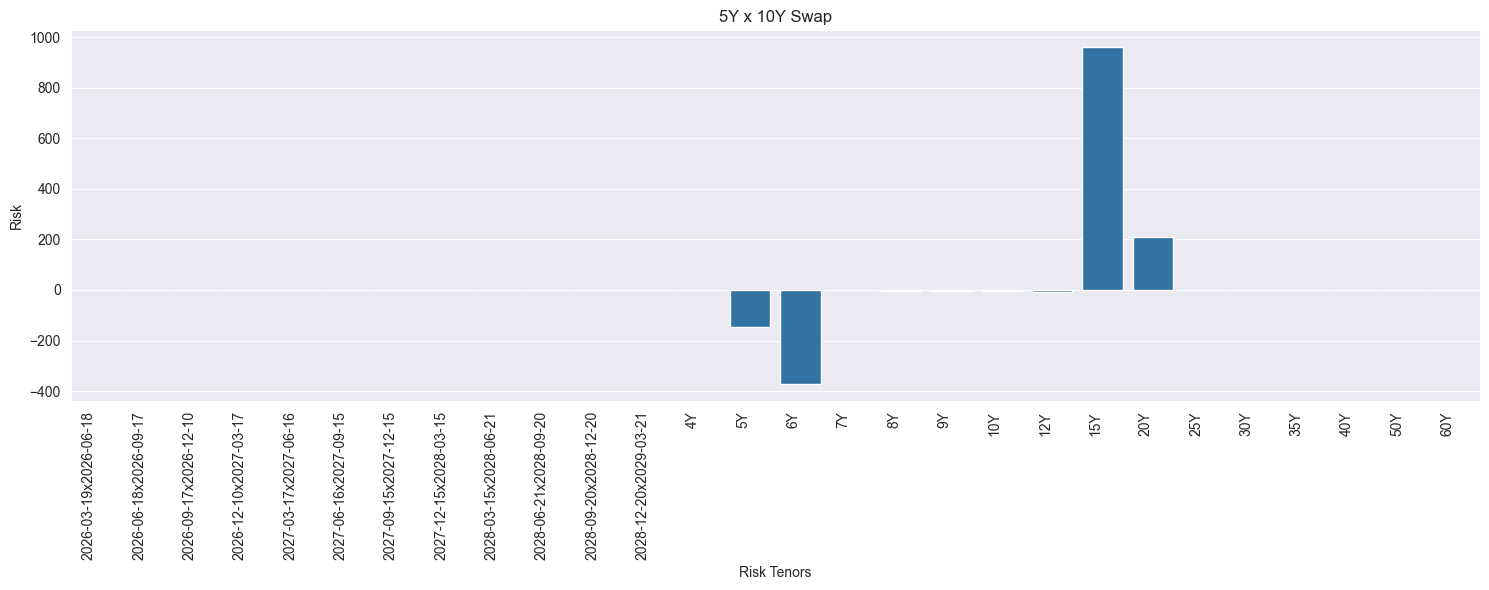

In [15]:

plt.figure(figsize=(15, 6)) 
sns.barplot(x='AXIS1', y='VALUES', data=df_risk)
plt.xticks(rotation=90, ha='right') # ha='right' often helps with alignment
plt.title('5Y x 10Y Swap')
plt.xlabel('Risk Tenors')
plt.ylabel('Risk')
plt.tight_layout()